<a href="https://colab.research.google.com/github/Anjanique-Knight/AjGIS/blob/main/AffordableHousingNJCounties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas

import geopandas as gpd
import zipfile

### Research ideas for a side by side map
- AMT CDBG AWARDED PER COUNTY
- HOW CDBG WAS SPENT PER COUNTY
-AVG COST OF AFFORDABLE HOUSING DEVELOPMENT
-AVG UNIT AMT OF AFFORDABLE HOUSING DEVELOPED
- AVG UNIT MIX OF AFFORDABLE HOUSING DEVELOPMENT

-AMT OF HOMELESSNESS PER COUNTY
-AMOUNT RENTERS WITH LOW INCOME

-AVG RENT PER COUNTY
-MEDIAN INCOME PER COUNTY
-RENT BURDEN PER COUNTY

-AVG PRICE OF AFFORDABLE HOUSING UNITS
-AVG INCOME QUALIFICATIONS FOR AFFORDABLE UNITS BY HOUSEHOLD SIZE
-AVG MAKEUP OF CURRENT AFFORDABLE HOUSING PROJECTS BY BEDROOM
-AVG HOUSEHOLD SIZE - BY BEDROOM NEED OR BY ADULT VS CHILDREN %

- '#' OF WOMEN RELEASED FROM INCARCERATION WITH DV/VIOLENT CRIMES
- '#' OF WOMEN RELEASED WITHOUT DIRECT HOME SUPPORT OR FACING HOMELESSNESS
- '#' OF REENTRY/ GROUP HOMES FOR WOMEN

# **Affordable Housing in NJ Counties - Anjanique Kent**


---


**Research Question:** Which NJ Counties may have the greatest need for affordable housing


---


**Reason:** Both my professional and educational interests include researching the current housing crisis not only in NJ but throughout the US.  As a Property Manager by profession, My duties include reviewing prospect income documents, and household demographics, while also performing market surveys to understand the current market price of housing units.  I believe by understanding what areas of NJ have the greatest need for affordable housing I can begin to develop a plan to bring such developments to fruition.


---
**Unit of Analysis:**

NJ Counties


---



**Planned Variables:**

Avg rent price
Household Income
Rent Burden
Unit availability

Future variables...
Household makeup - i.e. nuclear families, kinship, etc,
Job availability,
Disposable income,
Small business development,
Environmental impacts

---


**Data Source(LINK):**
https://catalog.data.gov/dataset/tiger-line-shapefile-current-state-new-jersey-county-subdivision

In [17]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd

import mapclassify
import seaborn as sns

In [1]:
!pip install geopandas

import geopandas as gpd
import zipfile


In [15]:
!wget -O NJ_Counties_3857.zip https://github.com/Anjanique-Knight/AjGIS/blob/main/NJ_Counties_3857_2520527434192953465.zip?raw=true

--2026-09-25 12:46:43--  https://github.com/Anjanique-Knight/AjGIS/blob/main/NJ_Counties_3857_2520527434192953465.zip?raw=true
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/Anjanique-Knight/AjGIS/raw/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip [following]
--2026-09-25 12:46:43--  https://github.com/Anjanique-Knight/AjGIS/raw/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Anjanique-Knight/AjGIS/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip [following]
--2026-09-25 12:46:43--  https://raw.githubusercontent.com/Anjanique-Knight/AjGIS/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108

In [24]:
zip_ref = zipfile.ZipFile('NJ_Counties_3857.zip', 'r'); zip_ref.extractall(); zip_ref.close()
!ls
NJC_3857=gpd.read_file('NJ_Counties_3857.shp')

NJ_Counties_3857_2520527434192953465.zip  nj_munis.dbf
NJ_Counties_3857.cpg			  nj_munis_fgdc.xml
NJ_Counties_3857.dbf			  nj_munis.prj
NJ_Counties_3857.prj			  nj_munis.sbn
NJ_Counties_3857.shp			  nj_munis.sbx
NJ_Counties_3857.shp.xml		  nj_munis.shp
NJ_Counties_3857.shx			  nj_munis.shp.xml
NJ_Counties_3857.zip			  nj_munis.shx
nj_counties.cpg				  nj_state.cpg
nj_counties.dbf				  nj_state.dbf
nj_counties_fgdc.xml			  nj_state_fgdc.xml
nj_counties.prj				  nj_state.prj
nj_counties.sbn				  nj_state.sbn
nj_counties.sbx				  nj_state.sbx
nj_counties.shp				  nj_state.shp
nj_counties.shp.xml			  nj_state.shp.xml
nj_counties.shx				  nj_state.shx
nj-countiess.zip			  sample_data
nj_munis.cpg


<Axes: >

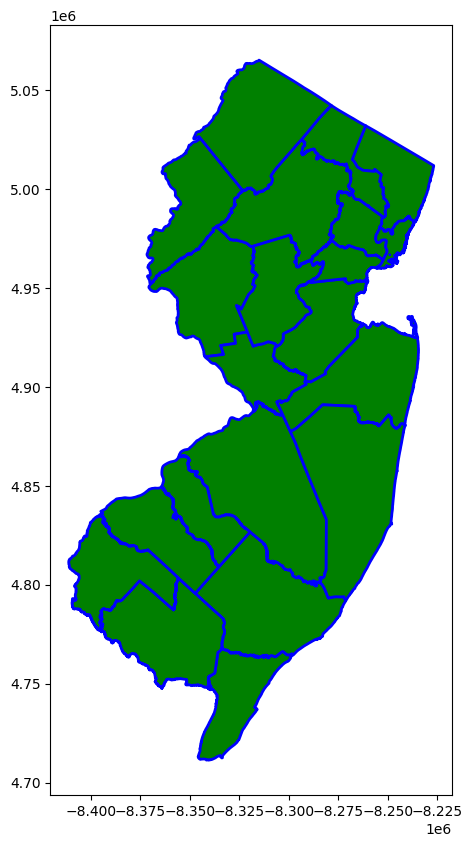

In [38]:
NJC_3857.plot(color='green', edgecolor='blue', linewidth=2, figsize=(8,10))

In [84]:
NJC_3857=gpd.read_file('NJ_Counties_3857.shp')

In [89]:
NJCO=NJC_3857[['COUNTY', 'POPDEN2020', 'POP2020', 'geometry']]

In [90]:
NJC_3857.dtypes

,0
COUNTY,object
COUNTY_LAB,object
CO,object
GNIS_NAME,object
GNIS,object
FIPSSTCO,object
FIPSCO,object
ACRES,float64
SQ_MILES,float64
POP2020,int64


In [41]:
NJC_3857.head()

,COUNTY,COUNTY_LAB,CO,GNIS_NAME,GNIS,FIPSSTCO,FIPSCO,ACRES,SQ_MILES,POP2020,...,POP2000,POP1990,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,REGION,geometry
0,ATLANTIC,Atlantic County,ATL,County of Atlantic,882270,34001,1,390813.840968,610.646627,274534,...,252552,275372,204615,450,450,414,451,335,COASTAL,"POLYGON ((-8312713.282 4820790.797, -8312708.3..."
1,BERGEN,Bergen County,BER,County of Bergen,882271,34003,3,153491.054911,239.829773,955732,...,884118,829592,849843,3985,3774,3686,3459,3544,NORTHEASTERN,"POLYGON ((-8227143.658 5009857.214, -8227168.3..."
2,BURLINGTON,Burlington County,BUR,County of Burlington,882272,34005,5,524901.239967,820.158187,461860,...,423394,395066,362542,563,547,516,482,442,SOUTHERN,"POLYGON ((-8315414.947 4892462.575, -8315385.2..."
3,CAMDEN,Camden County,CAM,County of Camden,882273,34007,7,145594.972008,227.492144,523485,...,508932,532498,471650,2301,2258,2237,2341,2073,SOUTHERN,"POLYGON ((-8352650.407 4865191.068, -8352634.3..."
4,CAPE MAY,Cape May County,CAP,County of Cape May,882274,34009,9,183125.841721,286.134128,95263,...,102326,95089,82266,333,340,358,332,288,COASTAL,"POLYGON ((-8333334.7 4767465.182, -8333326.647..."


In [50]:
NJC_3857.info

<bound method DataFrame.info of         COUNTY  POPDEN2020                                           geometry
0     ATLANTIC         450  POLYGON ((-8312713.282 4820790.797, -8312708.3...
1       BERGEN        3985  POLYGON ((-8227143.658 5009857.214, -8227168.3...
2   BURLINGTON         563  POLYGON ((-8315414.947 4892462.575, -8315385.2...
3       CAMDEN        2301  POLYGON ((-8352650.407 4865191.068, -8352634.3...
4     CAPE MAY         333  POLYGON ((-8333334.7 4767465.182, -8333326.647...
5   CUMBERLAND         307  POLYGON ((-8355847.558 4803471.275, -8352785.3...
6        ESSEX        6657  POLYGON ((-8273549.331 4998887.941, -8273546.3...
7   GLOUCESTER         900  POLYGON ((-8363274.44 4848913.536, -8363252.89...
8       HUDSON       14066  MULTIPOLYGON (((-8255557.166 4960158.087, -825...
9    HUNTERDON         295  POLYGON ((-8333637.616 4978513.722, -8333388.3...
10      MERCER        1693  POLYGON ((-8318028.639 4920619.895, -8318029.1...
11   MIDDLESEX        2723  POLYGON ((-8270529.978 4952808.632, -8270035.3...
12    MONMOUTH        1325  MULTIPOLYGON (((-8236603.336 4927584.644, -823...
13      MORRIS        1058  POLYGON ((-8293356.454 5025036.08, -8293352.55...
14       OCEAN         841  POLYGON ((-8266732.882 4890220.9, -8266724.401...
15     PASSAIC        2641  POLYGON ((-8276205.351 5040812.845, -8274460.1...
16       SALEM         187  POLYGON ((-8394264.296 4834757.726, -8394253.8...
17    SOMERSET        1133  POLYGON ((-8299372.578 4976530.133, -8299366.1...
18      SUSSEX         269  POLYGON ((-8312316.89 5063566.243, -8310486.03...
19       UNION        5460  POLYGON ((-8277138.463 4973116.079, -8277073.5...
20      WARREN         302  POLYGON ((-8342208.184 5022551.865, -8340901.0...>

In [45]:
NJC_3857['COUNTY'].value_counts()

,count
COUNTY,
ATLANTIC,1
BERGEN,1
BURLINGTON,1
CAMDEN,1
CAPE MAY,1
CUMBERLAND,1
ESSEX,1
GLOUCESTER,1
HUDSON,1


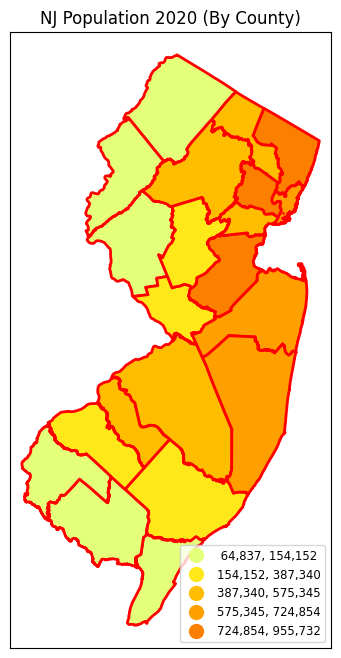

In [170]:
from matplotlib import legend
fig, ax = plt.subplots(1, figsize=(5,8))
NJCO.plot(ax=ax,column='POP2020', cmap='Wistia',scheme='natural_breaks', k=5, linewidth=2, edgecolor='red', legend=True, legend_kwds={"fmt": "{:,.0f}", 'loc':'lower right', 'title_fontsize':'medium', 'fontsize':'small', 'markerscale':1.10})
ax.title.set_text("NJ Population 2020 (By County)")
ax.set_xticks([])
ax.set_yticks([])
ax.margins(0.04)

In [227]:
!wget -q -O ahnj.xlsx https://github.com/Anjanique-Knight/AjGIS/raw/main/DCA-AHDataSummary.xlsx
ahnj_df = pd.read_excel('DCA-AHDataSummary.xlsx')
ahnj_df.head(100)

,"Affordable Housing Municipal Status Report as of March 6, 2025",Unnamed: 1,"Affordable Housing Municipal Status Report as of March 6, 2025.1",Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44
0,NaN,NaN,Affordable Unit Summary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Project Information,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Affordability Controls,NaN,NaN,NaN
2,Project ID,region_id,Name of Development/Project,DCA Muni Code,Taxation Muni Code,Municipality,County,Date Building Permit Issued,Certificate of Occupancy Granted,Date Certificate of Occupancy Issued,...,2&3 BDRM TAGS,1&3 BDRM TAGS,EFF&1 BDRM TAGS,EFF&2 BDRM TAGS,EFF&3 BDRM TAGS,Bedrooms Unknown,Beginning Date of Earliest Affordability Controls,Expiration Date of Earliest Affordability Cont...,Affordability Restriction Term (in Years) - Ea...,*blue font: Calculated by DCA based on control...
3,22389,100101,ABSECON GARDENS,0101,0101,Absecon city,Atlantic,--,--,--,...,--,--,--,--,--,--,--,--,--,NaN
4,22390,100101,CLAYTON MILL RUN,0101,0101,Absecon city,Atlantic,--,--,--,...,--,--,--,--,--,--,--,--,--,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,22542,100111,NANTUCKET AT GALLOWAY,0111,0111,Galloway township,Atlantic,--,--,--,...,--,--,--,--,--,--,--,--,--,NaN
96,2374,100111,PRESBYTERIAN HOMES,0111,0111,Galloway township,Atlantic,--,--,--,...,0,0,0,0,0,0,1996-09-20 00:00:00,2036-09-20 00:00:00,40,NaN
97,9913,100111,SEASHORE GARDENS INDEPENDENT LIVING CENTER,0111,0111,Galloway township,Atlantic,--,--,--,...,0,0,0,0,0,47,2010-05-27 00:00:00,2055-05-27 00:00:00,45,NaN
98,14517,100111,SEASHORE GARDENS SUPPORTIVE HOUSING,0111,0111,Galloway township,Atlantic,--,--,--,...,0,0,0,0,0,9,2009-05-04 00:00:00,2054-05-04 00:00:00,45,NaN


In [228]:
ahnj_xlsx1=ahnj_df[['Affordable Housing Municipal Status Report as of March 6, 2025.1', 'Unnamed: 5','Unnamed: 6']]
ahnj_xlsx1.rename(columns={'Affordable Housing Municipal Status Report as of March 6, 2025.1': "Community Name"}, inplace=True)
ahnj_xlsx1.rename(columns={'Unnamed: 5': "Municipality"}, inplace=True)
ahnj_xlsx1.rename(columns={'Unnamed: 6': "County"}, inplace=True)
# Corrected slicing to remove the first 3 rows which are part of the header
ahnj_xlsx1 = ahnj_xlsx1.iloc[3:].copy()

/tmp/ipykernel_1139/2805316605.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahnj_xlsx1.rename(columns={'Affordable Housing Municipal Status Report as of March 6, 2025.1': "Community Name"}, inplace=True)
/tmp/ipykernel_1139/2805316605.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahnj_xlsx1.rename(columns={'Unnamed: 5': "Municipality"}, inplace=True)
/tmp/ipykernel_1139/2805316605.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus

In [231]:
ahnj_xlsx1.head()

,Community Name,Municipality,County


In [252]:
ahnj_df=pd.merge(NJCO, ahnj_xlsx1, left_on='COUNTY', right_on='County', how='inner', indicator='True')
ahnj_df.head(45)

,COUNTY,POPDEN2020,POP2020,geometry,Community Name,Municipality,County,True
